# Sales level shift — confronto tra LSTM forecasting e Autoencoder

Il notebook confronta due approcci per rilevare anomalie di tipo `level_shift`:

- **LSTM forecasting-based**: utilizza le previsioni e i risultati già prodotti dalla sensitivity analysis;
- **LSTM Autoencoder reconstruction-based**: ricostruisce finestre temporali di vendite e usa l'errore di ricostruzione come score.

Entrambi gli approcci sono valutati a livello di evento. La ground truth serve esclusivamente a misurare le prestazioni finali.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm.auto import tqdm
from IPython.display import display

from tensorflow.keras.callbacks import EarlyStopping

from project_paths import (
    CLEAN_DATA_PATH,
    LEVEL_SHIFT_RESULTS_DIR,
    LEVEL_SHIFT_SENSITIVITY_DIR,
    MODELS_DIR,
    ensure_artifact_directories,
)

from lstm_utils import build_sales_ae_inputs

from sales_level_shift_utils import (
    build_pooled_summary,
    build_sales_ae_dataset,
    build_sales_lstm_autoencoder,
    list_sensitivity_datasets,
    run_sales_ae_detector_on_dataset,
)

pd.set_option("display.max_columns", None)

## Configurazione e cache

La LSTM non viene né ricaricata né rieseguita: il confronto riusa il CSV generato dal notebook di severity con la configurazione base del detector.

La griglia degli Autoencoder varia `window_size` e `latent_dim`. Ogni configurazione conserva modello, scaler, mapping e feature nella propria directory.

Con i flag predefiniti:
- se esiste il CSV raw del confronto, il notebook ricalcola soltanto tabelle e figure;
- se il CSV raw non esiste, riusa le cache per coppia dataset/configurazione AE;
- `FORCE_RECOMPUTE_RESULTS = True` ignora il CSV raw e le cache delle valutazioni;
- `RETRAIN_AE_MODELS = True` riaddestra gli AE e aggiorna anche le relative valutazioni.

In [3]:
ensure_artifact_directories()

BASE_SENSITIVITY_PATH = LEVEL_SHIFT_SENSITIVITY_DIR

AE_MODEL_ROOT = MODELS_DIR

OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "ae_vs_lstm_comparison"
CACHE_DIR = OUTPUT_DIR / "_cache"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for path in [OUTPUT_DIR, CACHE_DIR, FIGURES_DIR, TABLES_DIR, AE_MODEL_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

AE_WINDOW_SIZES = [7, 14, 21]
AE_LATENT_DIMS = [4, 8, 16]

AE_CONFIGS = [
    (window_size, latent_dim)
    for window_size in AE_WINDOW_SIZES
    for latent_dim in AE_LATENT_DIMS
]

AE_EPOCHS = 100
AE_BATCH_SIZE = 64
AE_PATIENCE = 20
AE_LEARNING_RATE = 1e-3

RETRAIN_AE_MODELS = False
FORCE_RECOMPUTE_RESULTS = False
DEBUG_MAX_DATASETS = None

AE_SCORE_COL = "ae_mae_score"
AE_N_STD = 3.5
AE_MIN_CONSECUTIVE = 3
AE_GAP_TOLERANCE = 1

LSTM_SCORE_WINDOW = 7
LSTM_N_STD = 3.5
LSTM_MIN_CONSECUTIVE = 3
LSTM_GAP_TOLERANCE = 1

IOU_THRESHOLD = 0.20
TRAIN_SIZE = 0.70
VAL_SIZE = 0.10
GLOBAL_SEED = 42

RAW_RESULTS_PATH = OUTPUT_DIR / "ae_vs_lstm_raw_results.csv"
MODEL_SUMMARY_PATH = TABLES_DIR / "ae_vs_lstm_model_summary.csv"
BEST_COMPARISON_PATH = TABLES_DIR / "ae_vs_lstm_best_comparison.csv"

LSTM_SEVERITY_RESULTS_PATH = (
    LEVEL_SHIFT_RESULTS_DIR
    / "lstm_severity"
    / "level_shift_severity_raw_results.csv"
)

np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

## Dataset di sensitivity

Ogni dataset identifica una combinazione di direzione, durata, moltiplicatore e seed. Gli eventi `level_shift` sono iniettati soltanto nel test set; train e validation restano il riferimento normale per l'addestramento degli AE e per la calibrazione delle soglie.

In [4]:
if not BASE_SENSITIVITY_PATH.exists():
    raise FileNotFoundError(f"Cartella sensitivity non trovata: {BASE_SENSITIVITY_PATH}")

datasets_df = list_sensitivity_datasets(BASE_SENSITIVITY_PATH)

datasets_df = datasets_df.sort_values(
    ["direction", "duration", "multiplier", "seed"]
).reset_index(drop=True)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset:", len(datasets_df))
display(datasets_df.head())

Numero dataset: 280


,path,direction,duration,multiplier,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,46


## Autoencoder: utility condivise e artifact

Il preprocessing, la costruzione dell’architettura, gli score di ricostruzione e la trasformazione delle finestre in eventi sono centralizzati in `sales_level_shift_utils.py`.

La griglia varia la lunghezza della finestra e la dimensione latente. Per ogni configurazione il notebook gestisce il salvataggio e il riuso di modello, scaler, mapping categorici, schema delle feature e history di training. Il caricamento e l’addestramento restano qui perché dipendono da path e flag dell’esperimento.

In [5]:
def get_ae_model_dir(window_size, latent_dim):
    return AE_MODEL_ROOT / (
        f"sales_AE_window_{window_size}_latent_{latent_dim}"
    )

def train_or_load_sales_ae(window_size, latent_dim, retrain=False):
    model_dir = get_ae_model_dir(window_size, latent_dim)

    model_path = model_dir / "lstm_sales_ae.keras"
    scalers_path = model_dir / "feature_scalers.pkl"
    mappings_path = model_dir / "mappings.pkl"
    features_path = model_dir / "features.pkl"
    history_path = model_dir / "training_history.csv"

    # Riusa il modello solo quando gli artifact di preprocessing sono completi.
    if (
        not retrain
        and model_path.exists()
        and scalers_path.exists()
        and mappings_path.exists()
        and features_path.exists()
    ):
        print(f"Carico AE window={window_size}, latent={latent_dim}")

        model = tf.keras.models.load_model(model_path, safe_mode=False)

        with open(scalers_path, "rb") as f:
            feature_scalers = pickle.load(f)

        with open(mappings_path, "rb") as f:
            mappings = pickle.load(f)

        with open(features_path, "rb") as f:
            features = pickle.load(f)

        return {
            "model": model,
            "feature_scalers": feature_scalers,
            "mappings": mappings,
            "features": features,
            "window_size": window_size,
            "latent_dim": latent_dim,
        }

    # Gli Autoencoder sono addestrati solo sul dataset clean.
    if not CLEAN_DATA_PATH.exists():
        raise FileNotFoundError(
            f"Dataset clean non trovato: {CLEAN_DATA_PATH}"
        )

    train_data_path = CLEAN_DATA_PATH

    print(f"Addestro AE window={window_size}, latent={latent_dim}")
    print("Dataset training AE:", train_data_path)

    clean_df = pd.read_csv(train_data_path)
    clean_df["date"] = pd.to_datetime(clean_df["date"])
    clean_df = clean_df.sort_values(["store_id", "date"]).reset_index(drop=True)

    train, val, _, feature_scalers, mappings, features = build_sales_ae_dataset(
        clean_df,
        window_size=window_size,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    train_inputs = build_sales_ae_inputs(train)
    val_inputs = build_sales_ae_inputs(val)

    model = build_sales_lstm_autoencoder(
        train,
        latent_dim=latent_dim,
        learning_rate=AE_LEARNING_RATE,
    )

    history = model.fit(
        train_inputs,
        train["y"],
        validation_data=(val_inputs, val["y"]),
        epochs=AE_EPOCHS,
        batch_size=AE_BATCH_SIZE,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=AE_PATIENCE,
                restore_best_weights=True,
            )
        ],
        verbose=1,
    )

    model_dir.mkdir(parents=True, exist_ok=True)

    model.save(model_path)

    with open(scalers_path, "wb") as f:
        pickle.dump(feature_scalers, f)

    with open(mappings_path, "wb") as f:
        pickle.dump(mappings, f)

    with open(features_path, "wb") as f:
        pickle.dump(features, f)

    pd.DataFrame(history.history).to_csv(history_path, index=False)

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "window_size": window_size,
        "latent_dim": latent_dim,
    }

In [6]:
ae_models = {}


def get_or_load_ae_model(window_size, latent_dim):
    # Carica una configurazione solo quando manca una sua cache.
    key = (window_size, latent_dim)

    if key not in ae_models:
        ae_models[key] = train_or_load_sales_ae(
            window_size=window_size,
            latent_dim=latent_dim,
            retrain=RETRAIN_AE_MODELS,
        )

    return ae_models[key]

## Risultati della LSTM forecasting-based

La componente LSTM viene letta dal CSV corrente prodotto dalla severity analysis. Il file contiene già i risultati della configurazione base del detector; qui vengono aggiunti solo i campi necessari allo schema comune di confronto.

In [7]:
def load_lstm_results_if_available():
    """Carica i risultati LSTM della severity analysis nella configurazione base."""

    if not LSTM_SEVERITY_RESULTS_PATH.exists():
        return None

    lstm = pd.read_csv(LSTM_SEVERITY_RESULTS_PATH)

    required_cols = [
        "direction",
        "duration",
        "multiplier",
        "seed",
        "n_gt_events",
        "n_detected_events",
        "tp",
        "fp",
        "fn",
        "precision",
        "recall",
        "f1",
        "mean_iou",
    ]

    missing_cols = [col for col in required_cols if col not in lstm.columns]

    if missing_cols:
        raise ValueError(
            "Il CSV della severity analysis non ha lo schema atteso.\n"
            f"File: {LSTM_SEVERITY_RESULTS_PATH}\n"
            f"Colonne mancanti: {missing_cols}"
        )

    # Il CSV contiene già i risultati della configurazione base.
    lstm = lstm.copy()

    # Allinea i risultati LSTM allo schema usato nel confronto con gli AE.
    lstm["model"] = "LSTM_forecasting"
    lstm["ae_window_size"] = np.nan
    lstm["ae_latent_dim"] = np.nan
    lstm["score_col"] = "level_shift_score"
    lstm["score_window"] = LSTM_SCORE_WINDOW
    lstm["n_std"] = LSTM_N_STD
    lstm["min_consecutive"] = LSTM_MIN_CONSECUTIVE
    lstm["gap_tolerance"] = LSTM_GAP_TOLERANCE
    lstm["iou_threshold"] = IOU_THRESHOLD

    return lstm

## Valutazione per dataset e cache dell'Autoencoder

Ogni cache contiene la sintesi event-level di una coppia dataset/configurazione AE. Quando il confronto deve essere aggiornato, le valutazioni già disponibili vengono riutilizzate salvo ricalcolo esplicito.

In [8]:
def make_ae_cache_path(row, window_size, latent_dim):
    # Una cache per ogni coppia dataset/configurazione AE.
    name = (
        f"ae_w{window_size}_z{latent_dim}_"
        f"{row['direction']}_dur{row['duration']}_"
        f"mult{float(row['multiplier']):.3f}_seed{int(row['seed'])}.pkl"
    )

    return CACHE_DIR / name.replace(".", "p")

## Esecuzione del confronto

Il CSV raw ha priorità: nella configurazione predefinita evita sia il caricamento degli Autoencoder sia le inferenze.

In assenza del CSV raw, il notebook controlla prima le cache per ciascuna coppia dataset/configurazione. Gli Autoencoder vengono caricati soltanto per le configurazioni con almeno una cache mancante.

In modalità debug, il CSV completo non viene sovrascritto con un sottoinsieme di dataset.

In [9]:
use_raw_results_cache = (
    RAW_RESULTS_PATH.exists()
    and not FORCE_RECOMPUTE_RESULTS
    and not RETRAIN_AE_MODELS
    and DEBUG_MAX_DATASETS is None
)

if use_raw_results_cache:
    # Il CSV finale evita sia il caricamento degli AE sia le inferenze.
    comparison_df = pd.read_csv(RAW_RESULTS_PATH)
    print("Risultati AE/LSTM caricati da:", RAW_RESULTS_PATH)

else:
    lstm_results = load_lstm_results_if_available()

    if lstm_results is None:
        raise FileNotFoundError(
            "Risultati LSTM non trovati nella severity analysis. "
            "Esegui prima 02_level_shift_severity."
        )

    comparison_rows = list(lstm_results.to_dict("records"))

    for _, row in tqdm(
        datasets_df.iterrows(),
        total=len(datasets_df),
        desc="AE datasets",
    ):
        for window_size, latent_dim in AE_CONFIGS:
            cache_path = make_ae_cache_path(
                row,
                window_size,
                latent_dim,
            )

            use_dataset_cache = (
                cache_path.exists()
                and not FORCE_RECOMPUTE_RESULTS
                and not RETRAIN_AE_MODELS
            )

            if use_dataset_cache:
                with open(cache_path, "rb") as f:
                    summary = pickle.load(f)
            else:
                ae_pack = get_or_load_ae_model(
                    window_size=window_size,
                    latent_dim=latent_dim,
                )

                summary = run_sales_ae_detector_on_dataset(
                    csv_path=row["path"],
                    ae_pack=ae_pack,
                    window_size=window_size,
                    score_col=AE_SCORE_COL,
                    n_std=AE_N_STD,
                    min_consecutive=AE_MIN_CONSECUTIVE,
                    gap_tolerance=AE_GAP_TOLERANCE,
                    iou_threshold=IOU_THRESHOLD,
                    train_size=TRAIN_SIZE,
                    val_size=VAL_SIZE,
                )

                summary.update({
                    "model": "AE_reconstruction",
                    "ae_window_size": window_size,
                    "ae_latent_dim": latent_dim,
                    "score_col": AE_SCORE_COL,
                    "direction": row["direction"],
                    "duration": row["duration"],
                    "multiplier": row["multiplier"],
                    "seed": row["seed"],
                    "dataset_path": str(row["path"]),
                    "score_window": np.nan,
                    "n_std": AE_N_STD,
                    "min_consecutive": AE_MIN_CONSECUTIVE,
                    "gap_tolerance": AE_GAP_TOLERANCE,
                    "iou_threshold": IOU_THRESHOLD,
                })

                with open(cache_path, "wb") as f:
                    pickle.dump(summary, f)

            comparison_rows.append(summary)

    comparison_df = pd.DataFrame(comparison_rows)

    if DEBUG_MAX_DATASETS is None:
        # Evita che un run di debug sovrascriva il risultato completo.
        comparison_df.to_csv(RAW_RESULTS_PATH, index=False)
        print("Risultati AE/LSTM salvati in:", RAW_RESULTS_PATH)
    else:
        print("Modalità debug: il CSV raw completo non viene sovrascritto.")

print("Shape:", comparison_df.shape)
display(comparison_df.head())
RAW_RESULTS_PATH

Risultati AE/LSTM caricati da: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\ae_vs_lstm_comparison\ae_vs_lstm_raw_results.csv
Shape: (2800, 26)


,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,mean_detection_det_offset_end,direction,duration,multiplier,severity_class,seed,model,ae_window_size,ae_latent_dim,score_col,score_window,n_std,min_consecutive,gap_tolerance,iou_threshold,dataset_path
0,40,66,40,26,0,0.606061,1.0,0.754717,0.447984,-5.625,3.050,decrease,7,0.7,hard,42,LSTM_forecasting,NaN,NaN,level_shift_score,7.0,3.5,3,1,0.2,NaN
1,40,63,40,23,0,0.634921,1.0,0.776699,0.443395,-5.675,3.300,decrease,7,0.7,hard,43,LSTM_forecasting,NaN,NaN,level_shift_score,7.0,3.5,3,1,0.2,NaN
2,40,64,40,24,0,0.625000,1.0,0.769231,0.440574,-5.750,3.300,decrease,7,0.7,hard,44,LSTM_forecasting,NaN,NaN,level_shift_score,7.0,3.5,3,1,0.2,NaN
3,40,61,40,21,0,0.655738,1.0,0.792079,0.446315,-5.725,3.075,decrease,7,0.7,hard,45,LSTM_forecasting,NaN,NaN,level_shift_score,7.0,3.5,3,1,0.2,NaN
4,40,66,40,26,0,0.606061,1.0,0.754717,0.450116,-5.750,2.850,decrease,7,0.7,hard,46,LSTM_forecasting,NaN,NaN,level_shift_score,7.0,3.5,3,1,0.2,NaN


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/ae_vs_lstm_comparison/ae_vs_lstm_raw_results.csv')

## Sintesi dei risultati

Le tabelle sono calcolate con conteggi pooled: vengono sommati prima `TP`, `FP` e `FN`, poi si ricavano precision, recall e \(F_1\). La IoU media è pesata per il numero di true positive.

In [10]:
model_summary = build_pooled_summary(
    comparison_df,
    ["model", "ae_window_size", "ae_latent_dim"],
)

model_summary = (
    model_summary
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

model_summary.to_csv(MODEL_SUMMARY_PATH, index=False)

lstm_summary = model_summary[
    model_summary["model"].eq("LSTM_forecasting")
].copy()

best_ae_summary = (
    model_summary[model_summary["model"].eq("AE_reconstruction")]
    .head(1)
    .copy()
)

best_comparison = pd.concat(
    [lstm_summary, best_ae_summary],
    ignore_index=True,
)

best_comparison.to_csv(BEST_COMPARISON_PATH, index=False)

model_summary_display = model_summary.copy()

for col in [
    "precision",
    "recall",
    "f1",
    "mean_iou",
    "f1_run_mean",
    "f1_run_std",
]:
    model_summary_display[col] = model_summary_display[col].round(3)

display(model_summary_display)
display(best_comparison.round(3))

MODEL_SUMMARY_PATH, BEST_COMPARISON_PATH

,model,ae_window_size,ae_latent_dim,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,f1_run_mean,f1_run_std
0,LSTM_forecasting,NaN,NaN,280,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.641,0.700,0.295
1,AE_reconstruction,21.0,8.0,280,11200,5997,4541,1484,6659,0.754,0.405,0.527,0.667,0.451,0.332
2,AE_reconstruction,21.0,16.0,280,11200,4683,3127,1562,8073,0.667,0.279,0.394,0.633,0.337,0.288
3,AE_reconstruction,21.0,4.0,280,11200,5246,2900,2354,8300,0.552,0.259,0.352,0.608,0.297,0.225
4,AE_reconstruction,14.0,4.0,280,11200,4154,1974,2180,9226,0.475,0.176,0.257,0.520,0.234,0.163
5,AE_reconstruction,14.0,8.0,280,11200,2187,1660,527,9540,0.759,0.148,0.248,0.573,0.224,0.236
6,AE_reconstruction,14.0,16.0,280,11200,1441,1267,174,9933,0.879,0.113,0.200,0.558,0.248,0.251
7,AE_reconstruction,7.0,8.0,280,11200,1668,1044,624,10156,0.626,0.093,0.162,0.486,0.176,0.156
8,AE_reconstruction,7.0,16.0,280,11200,1082,981,101,10219,0.907,0.088,0.160,0.522,0.185,0.189
9,AE_reconstruction,7.0,4.0,280,11200,1300,746,554,10454,0.574,0.067,0.119,0.479,0.143,0.085


,model,ae_window_size,ae_latent_dim,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,f1_run_mean,f1_run_std
0,LSTM_forecasting,NaN,NaN,280,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.641,0.700,0.295
1,AE_reconstruction,21.0,8.0,280,11200,5997,4541,1484,6659,0.754,0.405,0.527,0.667,0.451,0.332


(WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/ae_vs_lstm_comparison/tables/ae_vs_lstm_model_summary.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/ae_vs_lstm_comparison/tables/ae_vs_lstm_best_comparison.csv'))

## Tabella compatta per la tesi

Questa tabella mantiene le metriche utili al confronto e rimuove i conteggi tecnici impiegati nelle aggregazioni.

In [11]:
cols_to_drop = [
    "n_runs",
    "n_gt_events",
    "tp",
    "fp",
    "fn",
    "f1_run_mean",
    "f1_run_std",
]

model_summary_tesi = model_summary.drop(
    columns=cols_to_drop,
    errors="ignore"
)

model_summary_tesi["model"] = model_summary_tesi["model"].replace({
    "LSTM_forecasting": "LSTM",
    "AE_reconstruction": "AE"
})

model_summary_tesi

,model,ae_window_size,ae_latent_dim,n_detected_events,precision,recall,f1,mean_iou
0,LSTM,NaN,NaN,9211,0.825209,0.678661,0.744794,0.640558
1,AE,21.0,8.0,5997,0.753693,0.405446,0.527257,0.667457
2,AE,21.0,16.0,4683,0.666880,0.279196,0.393606,0.632965
3,AE,21.0,4.0,5246,0.551960,0.258929,0.352498,0.607575
4,AE,14.0,4.0,4154,0.475205,0.176250,0.257132,0.519605
5,AE,14.0,8.0,2187,0.759031,0.148214,0.248002,0.573407
6,AE,14.0,16.0,1441,0.879251,0.113125,0.200459,0.557807
7,AE,7.0,8.0,1668,0.625899,0.093214,0.162263,0.486325
8,AE,7.0,16.0,1082,0.906654,0.087589,0.159746,0.521743
9,AE,7.0,4.0,1300,0.573846,0.066607,0.119360,0.479139


## Analisi per intensità e moltiplicatore

Le aggregazioni successive mostrano come cambiano le metriche al variare dell'intensità dello shift e del moltiplicatore. I grafici confrontano la LSTM con le configurazioni AE migliori nella griglia valutata.

In [12]:
def assign_intensity_class(multiplier):
    delta = abs(float(multiplier) - 1.0)

    if delta <= 0.05:
        return "soft"
    if delta <= 0.15:
        return "medium"
    return "hard"

comparison_df["intensity_class"] = comparison_df["multiplier"].map(assign_intensity_class)

comparison_by_intensity = build_pooled_summary(
    comparison_df,
    ["model", "ae_window_size", "ae_latent_dim", "intensity_class"],
)

comparison_by_intensity.to_csv(
    TABLES_DIR / "ae_vs_lstm_comparison_by_intensity.csv",
    index=False,
)

comparison_by_multiplier = build_pooled_summary(
    comparison_df,
    ["model", "ae_window_size", "ae_latent_dim", "multiplier"],
)

comparison_by_multiplier.to_csv(
    TABLES_DIR / "ae_vs_lstm_comparison_by_multiplier.csv",
    index=False,
)

display(comparison_by_intensity.head())
display(comparison_by_multiplier.head())

,model,ae_window_size,ae_latent_dim,intensity_class,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,f1_run_mean,f1_run_std
0,AE_reconstruction,7.0,4.0,hard,100,4000,665,449,216,3551,0.675188,0.112250,0.192497,0.475425,0.186343,0.102338
1,AE_reconstruction,7.0,4.0,medium,140,5600,523,255,268,5345,0.487572,0.045536,0.083293,0.487983,0.114491,0.044305
2,AE_reconstruction,7.0,4.0,soft,40,1600,112,42,70,1558,0.375000,0.026250,0.049065,0.465142,0.081949,0.034234
3,AE_reconstruction,7.0,8.0,hard,100,4000,1003,739,264,3261,0.736790,0.184750,0.295423,0.481809,0.290571,0.185812
4,AE_reconstruction,7.0,8.0,medium,140,5600,542,262,280,5338,0.483395,0.046786,0.085314,0.502409,0.113684,0.054162


,model,ae_window_size,ae_latent_dim,multiplier,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,f1_run_mean,f1_run_std
0,AE_reconstruction,7.0,4.0,0.700,20,800,152,107,45,693,0.703947,0.13375,0.224790,0.440976,0.223020,0.069112
1,AE_reconstruction,7.0,4.0,0.800,20,800,86,51,35,749,0.593023,0.06375,0.115124,0.442262,0.114880,0.046893
2,AE_reconstruction,7.0,4.0,0.850,20,800,71,35,36,765,0.492958,0.04375,0.080367,0.453698,0.079985,0.054316
3,AE_reconstruction,7.0,4.0,0.900,20,800,51,16,35,784,0.313725,0.02000,0.037603,0.457291,0.074882,0.025341
4,AE_reconstruction,7.0,4.0,0.925,20,800,42,7,35,793,0.166667,0.00875,0.016627,0.496926,0.066478,0.024233


## Grafici

Le funzioni seguenti selezionano le configurazioni AE migliori in base alla \(F_1\) pooled e producono i grafici per moltiplicatore.

In [13]:
def format_multiplier_tick(x):
    return f"{x:.3f}".rstrip("0").rstrip(".")

def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path

def config_label(row):
    if row["model"] == "LSTM_forecasting":
        return "LSTM"

    return f"AE w={int(row['ae_window_size'])}, z={int(row['ae_latent_dim'])}"

# Le curve collegano separatamente shift negativi e positivi.

def plot_metric_by_multiplier_top_ae_models(
    comparison_by_multiplier,
    model_summary,
    metric_col,
    metric_label,
    file_name,
    top_k_ae=3
):
    top_ae_configs = (
        model_summary[model_summary["model"].eq("AE_reconstruction")]
        .sort_values("f1", ascending=False)
        .head(top_k_ae)[["ae_window_size", "ae_latent_dim"]]
    )

    mask_lstm = comparison_by_multiplier["model"].eq("LSTM_forecasting")

    mask_top_ae = pd.Series(False, index=comparison_by_multiplier.index)

    for _, row in top_ae_configs.iterrows():
        mask_top_ae |= (
            comparison_by_multiplier["model"].eq("AE_reconstruction")
            & comparison_by_multiplier["ae_window_size"].eq(row["ae_window_size"])
            & comparison_by_multiplier["ae_latent_dim"].eq(row["ae_latent_dim"])
        )

    plot_df = comparison_by_multiplier[mask_lstm | mask_top_ae].copy()

    fig, ax = plt.subplots(figsize=(10, 5))

    for _, g in plot_df.groupby(
        ["model", "ae_window_size", "ae_latent_dim"],
        dropna=False
    ):
        g = g.sort_values("multiplier")
        label = config_label(g.iloc[0])

        decrease = g[g["multiplier"] < 1].copy()
        increase = g[g["multiplier"] > 1].copy()

        color = None
        label_used = False

        if not decrease.empty:
            line, = ax.plot(
                decrease["multiplier"],
                decrease[metric_col],
                marker="o",
                linewidth=2.4,
                label=label,
            )
            color = line.get_color()
            label_used = True

        if not increase.empty:
            ax.plot(
                increase["multiplier"],
                increase[metric_col],
                marker="o",
                linewidth=2.4,
                color=color,
                label=None if label_used else label,
            )

    xticks = sorted(plot_df["multiplier"].dropna().unique())

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [format_multiplier_tick(x) for x in xticks],
        rotation=45
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Moltiplicatore")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} al variare del moltiplicatore")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="Modello")

    plt.tight_layout()
    path = save_figure(fig, file_name)
    plt.show()

    return path

def get_top_ae_configs(model_summary, top_k_ae=3):
    return (
        model_summary[model_summary["model"].eq("AE_reconstruction")]
        .sort_values("f1", ascending=False)
        .head(top_k_ae)[
            ["ae_window_size", "ae_latent_dim"]
        ]
        .reset_index(drop=True)
    )

def build_dashboard_plot_df(
    comparison_by_multiplier,
    model_summary,
    top_k_ae=3,
):
    top_ae_configs = get_top_ae_configs(
        model_summary=model_summary,
        top_k_ae=top_k_ae,
    )

    mask = comparison_by_multiplier["model"].eq("LSTM_forecasting")

    for _, row in top_ae_configs.iterrows():
        mask |= (
            comparison_by_multiplier["model"].eq("AE_reconstruction")
            & comparison_by_multiplier["ae_window_size"].eq(
                row["ae_window_size"]
            )
            & comparison_by_multiplier["ae_latent_dim"].eq(
                row["ae_latent_dim"]
            )
        )

    return comparison_by_multiplier[mask].copy(), top_ae_configs

def plot_metric_by_multiplier_on_axis(
    ax,
    plot_df,
    top_ae_configs,
    metric,
    title,
    linewidth=2.4,
    marker_size=5,
):
    df = plot_df.copy()

    if metric in ["recall", "f1"]:
        df[metric] = df[metric].fillna(0.0)

    plot_specs = [("LSTM_forecasting", None, None, "LSTM")]

    for _, row in top_ae_configs.iterrows():
        plot_specs.append(
            (
                "AE_reconstruction",
                row["ae_window_size"],
                row["ae_latent_dim"],
                (
                    f"AE w={int(row['ae_window_size'])}, "
                    f"z={int(row['ae_latent_dim'])}"
                ),
            )
        )

    for model_name, window_size, latent_dim, label in plot_specs:
        mask = df["model"].eq(model_name)

        if model_name == "AE_reconstruction":
            mask &= (
                df["ae_window_size"].eq(window_size)
                & df["ae_latent_dim"].eq(latent_dim)
            )

        g = df[mask].sort_values("multiplier").copy()

        if g.empty:
            continue

        decrease_part = g[g["multiplier"] < 1].copy()
        increase_part = g[g["multiplier"] > 1].copy()

        color = None

        if not decrease_part.empty:
            line, = ax.plot(
                decrease_part["multiplier"],
                decrease_part[metric],
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                label=label,
            )
            color = line.get_color()

        if not increase_part.empty:
            ax.plot(
                increase_part["multiplier"],
                increase_part[metric],
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                color=color,
                label=None if color is not None else label,
            )

    xticks = sorted(df["multiplier"].dropna().unique())

    ax.set_title(
        title,
        fontweight="bold",
    )

    ax.set_ylim(-0.05, 1.05)

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [format_multiplier_tick(x) for x in xticks],
        rotation=45,
        fontsize=9,
    )

    ax.grid(True, linestyle="--", alpha=0.35)

def plot_lstm_vs_top_ae_dashboard(
    comparison_by_multiplier,
    model_summary,
    filename="ae_vs_lstm_dashboard_by_multiplier_top3_ae.png",
    top_k_ae=3,
    linewidth=2.4,
    marker_size=5,
):
    plot_df, top_ae_configs = build_dashboard_plot_df(
        comparison_by_multiplier=comparison_by_multiplier,
        model_summary=model_summary,
        top_k_ae=top_k_ae,
    )

    fig = plt.figure(figsize=(14, 9))

    grid = fig.add_gridspec(
        nrows=2,
        ncols=4,
        height_ratios=[1, 1],
        hspace=0.25,
        wspace=0.22,
    )

    ax_precision = fig.add_subplot(grid[0, :2])
    ax_recall = fig.add_subplot(grid[0, 2:])
    ax_f1 = fig.add_subplot(grid[1, 1:3])

    plot_metric_by_multiplier_on_axis(
        ax=ax_precision,
        plot_df=plot_df,
        top_ae_configs=top_ae_configs,
        metric="precision",
        title="Precision",
        linewidth=linewidth,
        marker_size=marker_size,
    )

    plot_metric_by_multiplier_on_axis(
        ax=ax_recall,
        plot_df=plot_df,
        top_ae_configs=top_ae_configs,
        metric="recall",
        title="Recall",
        linewidth=linewidth,
        marker_size=marker_size,
    )

    plot_metric_by_multiplier_on_axis(
        ax=ax_f1,
        plot_df=plot_df,
        top_ae_configs=top_ae_configs,
        metric="f1",
        title=r"$\mathbf{F_1}$",
        linewidth=linewidth,
        marker_size=marker_size,
    )

    handles, labels = ax_precision.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Modello",
        loc="upper center",
        ncol=len(labels),
        frameon=True,
        fancybox=False,
        bbox_to_anchor=(0.5, 0.98),
    )

    fig.suptitle(
        "Confronto tra LSTM e Autoencoder al variare del moltiplicatore",
        y=1.01,
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])

    path = save_figure(fig, filename)
    plt.show()

    return path

C:\Users\ciok4\AppData\Local\Temp\ipykernel_83604\3782063022.py:301: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.91])


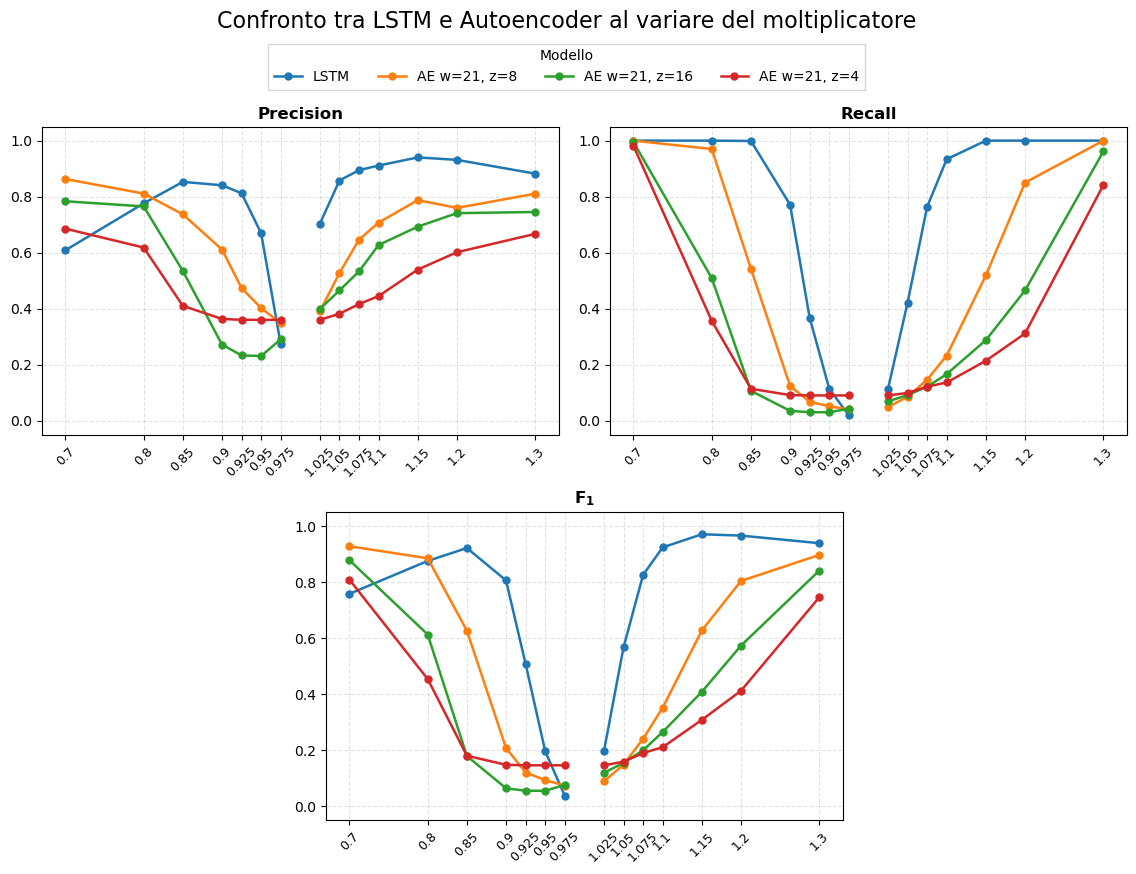

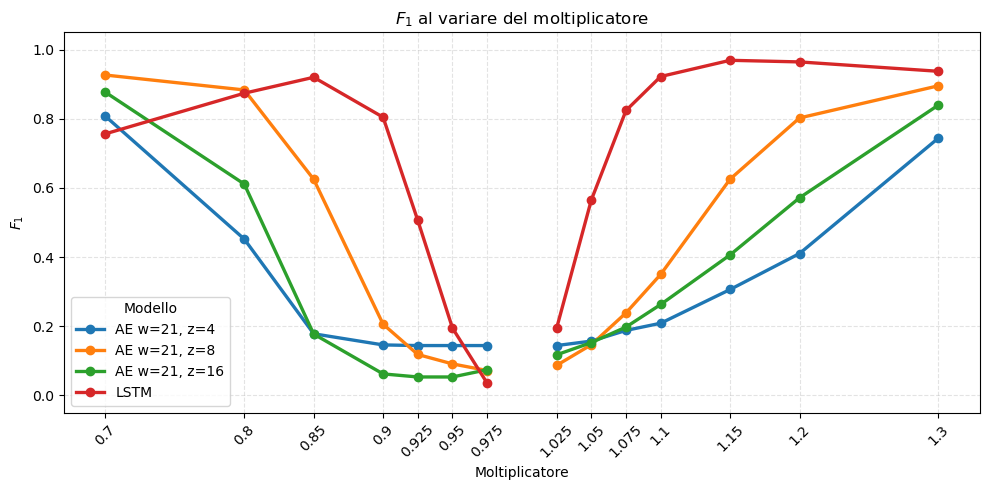

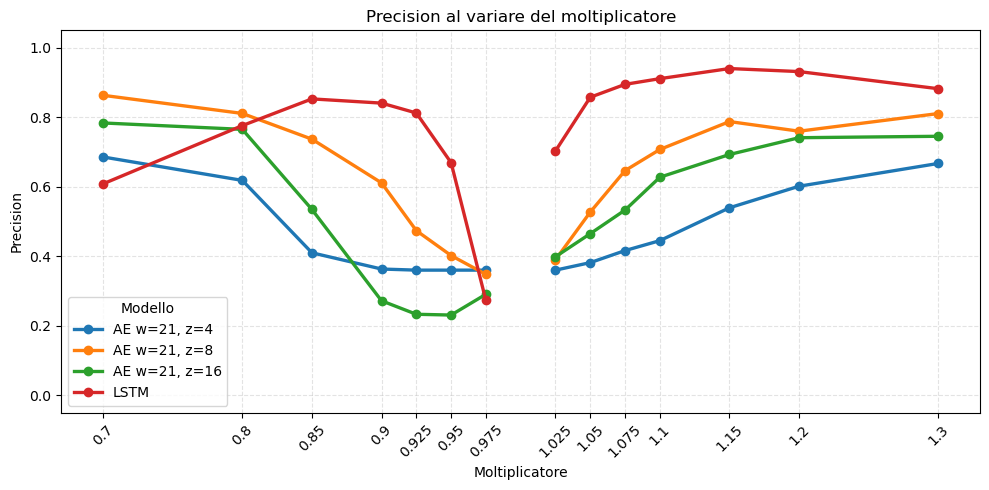

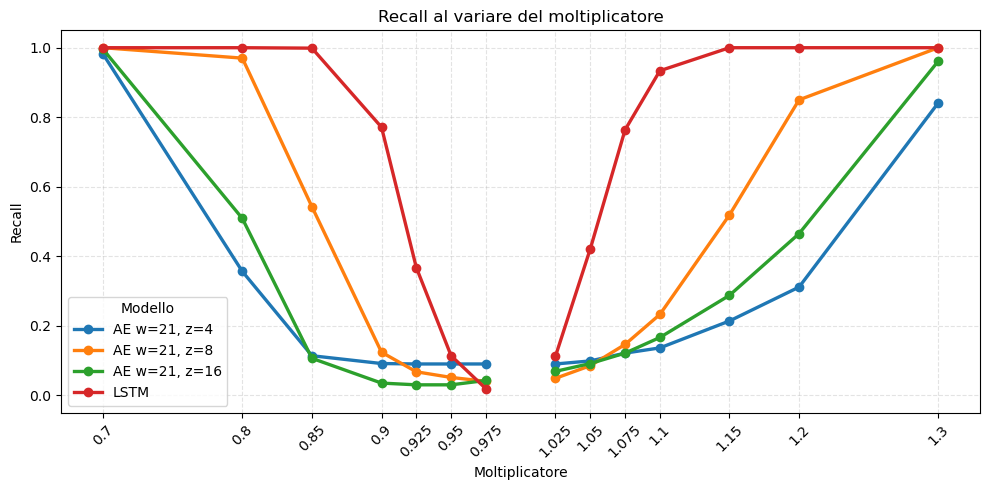

(WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/ae_vs_lstm_comparison/figures/ae_vs_lstm_f1_by_multiplier_top3_ae.png'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/ae_vs_lstm_comparison/figures/ae_vs_lstm_precision_by_multiplier_top3_ae.png'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/ae_vs_lstm_comparison/figures/ae_vs_lstm_recall_by_multiplier_top3_ae.png'))

In [14]:
dashboard_path = plot_lstm_vs_top_ae_dashboard(
    comparison_by_multiplier=comparison_by_multiplier,
    model_summary=model_summary,
    top_k_ae=3,
    linewidth=1.8,
    marker_size=5,
)

dashboard_path

f1_multiplier_path = plot_metric_by_multiplier_top_ae_models(
    comparison_by_multiplier=comparison_by_multiplier,
    model_summary=model_summary,
    metric_col="f1",
    metric_label=r"$F_1$",
    file_name="ae_vs_lstm_f1_by_multiplier_top3_ae.png",
    top_k_ae=3,
)

precision_multiplier_path = plot_metric_by_multiplier_top_ae_models(
    comparison_by_multiplier=comparison_by_multiplier,
    model_summary=model_summary,
    metric_col="precision",
    metric_label="Precision",
    file_name="ae_vs_lstm_precision_by_multiplier_top3_ae.png",
    top_k_ae=3,
)

recall_multiplier_path = plot_metric_by_multiplier_top_ae_models(
    comparison_by_multiplier=comparison_by_multiplier,
    model_summary=model_summary,
    metric_col="recall",
    metric_label="Recall",
    file_name="ae_vs_lstm_recall_by_multiplier_top3_ae.png",
    top_k_ae=3,
)

f1_multiplier_path, precision_multiplier_path, recall_multiplier_path

## Artifact prodotti

Il notebook salva il CSV raw, le sintesi pooled, il confronto LSTM–miglior AE e le figure nella directory degli artifact del caso `level_shift`.

In [15]:
print("Raw results:", RAW_RESULTS_PATH)
print("Model summary:", MODEL_SUMMARY_PATH)
print("Best comparison:", BEST_COMPARISON_PATH)
print("Figures:", FIGURES_DIR)
print("Tables:", TABLES_DIR)

Raw results: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\ae_vs_lstm_comparison\ae_vs_lstm_raw_results.csv
Model summary: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\ae_vs_lstm_comparison\tables\ae_vs_lstm_model_summary.csv
Best comparison: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\ae_vs_lstm_comparison\tables\ae_vs_lstm_best_comparison.csv
Figures: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\ae_vs_lstm_comparison\figures
Tables: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\ae_vs_lstm_comparison\tables
